In [1]:
!pip install torch-geometric -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.9 MB/s eta 0:00:00a 0:00:01


In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GATConv
import networkx as nx
from sklearn.metrics import roc_auc_score, average_precision_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

dataset = ["dataset/soc-redditHyperlinks-body.tsv", "dataset/soc-redditHyperlinks-title.tsv"]
train_ratio, val_ratio = 0.70, 0.15

In [4]:
frames = []
for subset in dataset:
    df = pd.read_csv(subset, sep='\t', usecols=[0, 1, 3],
                    names=["src", "tgt", "time"], header=0)
    frames.append(df)
df = pd.concat(frames, ignore_index=True)
df['time'] = pd.to_datetime(df['time']).astype('int64')
df = df.sort_values("time").reset_index(drop=True)

In [5]:
all_nodes = pd.unique(df[["src", "tgt"]].values.ravel())
node2id = {n: i for i, n in enumerate(all_nodes)}
df["src"] = df["src"].map(node2id)
df["tgt"] = df["tgt"].map(node2id)
num_nodes     = len(node2id)
print(f"Loaded {len(df)} edges | {num_nodes} unique nodes")
print(f"Time range: {df['time'].min()} → {df['time'].max()}")

n = len(df)
t_train = int(n * train_ratio)
t_val   = int(n * (train_ratio + val_ratio))
train_df = df.iloc[:t_train]
val_df   = df.iloc[t_train:t_val]
test_df  = df.iloc[t_val:]
print(f"Split → train:{len(train_df)} | val:{len(val_df)} | test:{len(test_df)}")

Loaded 858488 edges | 67180 unique nodes
Time range: 1388506820000000000 → 1493571501000000000
Split → train:600941 | val:128773 | test:128774


In [6]:
class TimeEncoder(nn.Module):
    """
    Bochner's theorem cosine basis (TGAT-style).
    Maps scalar Δt → R^{out_dim}.
    """
    def __init__(self, out_dim: int):
        super().__init__()
        self.w = nn.Linear(1, out_dim)
        nn.init.xavier_uniform_(self.w.weight)
 
    def forward(self, t: torch.Tensor) -> torch.Tensor:
        return torch.cos(self.w(t.unsqueeze(-1).float()))   # (*, out_dim)


class NodeMemory(nn.Module):
    """
    Persistent per-node memory inspired by TGN (Rossi et al., 2020).
 
    Each node i maintains a hidden state  m_i ∈ R^{mem_dim}  that is
    updated via a GRU cell every time the node appears as src or tgt
    in an interaction.
 
    Message function:
        raw_msg_src(i) = [ m_i ‖ m_j ‖ Δt_enc(t - last_t_i) ]
        raw_msg_tgt(j) = [ m_j ‖ m_i ‖ Δt_enc(t - last_t_j) ]
 
    The message is projected by msg_mlp, then fed into a GRU:
        m_i ← GRU( msg_mlp(raw_msg_i), m_i )
 
    Memory is detached from the computation graph between batches
    (acts as a learned, persistent embedding store).
    """
 
    def __init__(self, num_nodes: int, mem_dim: int, time_dim: int,
                 msg_dim: int = None):
        super().__init__()
        self.num_nodes = num_nodes
        self.mem_dim   = mem_dim
        self.time_dim  = time_dim
        msg_dim        = msg_dim or mem_dim
 
        self.time_enc  = TimeEncoder(time_dim)
 
        # raw message = [m_src ‖ m_tgt ‖ Δt_enc]  → 2*mem_dim + time_dim
        raw_msg_dim    = 2 * mem_dim + time_dim
        self.msg_mlp   = nn.Sequential(
            nn.Linear(raw_msg_dim, msg_dim),
            nn.ReLU(),
            nn.Linear(msg_dim, msg_dim),
        )
        self.gru_cell  = nn.GRUCell(msg_dim, mem_dim)
 
        # Persistent buffers — not optimised by gradient descent
        self.register_buffer("memory",    torch.zeros(num_nodes, mem_dim))
        self.register_buffer("last_time", torch.zeros(num_nodes))
 
    # ── helpers ──────────────────────────────
 
    def reset(self):
        """Zero all memory (call before each epoch)."""
        self.memory.zero_()
        self.last_time.zero_()
 
    def detach(self):
        """Detach memory from autograd graph (call after each update)."""
        self.memory    = self.memory.detach()
        self.last_time = self.last_time.detach()
 
    def get_memory(self, node_ids: torch.Tensor) -> torch.Tensor:
        """Retrieve memory for a set of node ids.  (B, mem_dim)"""
        return self.memory[node_ids]
 
    # ── core update ──────────────────────────
 
    def update(self, src: torch.Tensor, tgt: torch.Tensor,
               t: torch.Tensor) -> None:
        """
        Update memory for all unique nodes involved in (src, tgt, t).
 
        Args:
            src : (E,) source node ids
            tgt : (E,) target node ids
            t   : (E,) normalised interaction timestamps
        """
        # Retrieve current memories
        m_src = self.memory[src]                              # (E, mem_dim)
        m_tgt = self.memory[tgt]                              # (E, mem_dim)
 
        # Time deltas since each node's last interaction
        dt_src = (t - self.last_time[src]).clamp(min=0)      # (E,)
        dt_tgt = (t - self.last_time[tgt]).clamp(min=0)      # (E,)
 
        te_src = self.time_enc(dt_src)                        # (E, time_dim)
        te_tgt = self.time_enc(dt_tgt)                        # (E, time_dim)
 
        # Build messages for source nodes and target nodes separately
        msg_for_src = self.msg_mlp(torch.cat([m_src, m_tgt, te_src], dim=-1))
        msg_for_tgt = self.msg_mlp(torch.cat([m_tgt, m_src, te_tgt], dim=-1))
 
        # Aggregate messages per unique node (mean pooling over multi-edges)
        unique_nodes = torch.unique(torch.cat([src, tgt]))
        agg_msg      = torch.zeros(self.num_nodes, msg_for_src.size(-1),
                                   device=self.memory.device)
        cnt          = torch.zeros(self.num_nodes, 1, device=self.memory.device)
 
        agg_msg.scatter_add_(0, src.unsqueeze(-1).expand_as(msg_for_src), msg_for_src)
        agg_msg.scatter_add_(0, tgt.unsqueeze(-1).expand_as(msg_for_tgt), msg_for_tgt)
        cnt.scatter_add_(0, src.unsqueeze(-1), torch.ones(len(src), 1, device=self.memory.device))
        cnt.scatter_add_(0, tgt.unsqueeze(-1), torch.ones(len(tgt), 1, device=self.memory.device))
 
        cnt = cnt.clamp(min=1)
        agg_msg_unique = agg_msg[unique_nodes] / cnt[unique_nodes]
 
        # GRU update for involved nodes
        new_mem = self.gru_cell(agg_msg_unique,
                                self.memory[unique_nodes])    # (U, mem_dim)
        self.memory[unique_nodes] = new_mem
 
        # Update last-seen timestamps
        self.last_time.scatter_reduce_(0, src, t, reduce="amax", include_self=True)
        self.last_time.scatter_reduce_(0, tgt, t, reduce="amax", include_self=True)
 
    def forward(self, node_ids: torch.Tensor) -> torch.Tensor:
        """Return memory for node_ids.  Convenience alias."""
        return self.get_memory(node_ids)


class TemporalGNN(nn.Module):
    """
    Two-layer GAT.  Input = [node_feat ‖ memory ‖ time_enc]  per node.
    """
    def __init__(self, node_feat_dim: int, mem_dim: int, time_dim: int,
                 hidden_dim: int, out_dim: int,
                 heads: int = 4, dropout: float = 0.2):
        super().__init__()
        self.time_enc = TimeEncoder(time_dim)
        in_dim        = node_feat_dim + mem_dim + time_dim
 
        self.conv1 = GATConv(in_dim,             hidden_dim, heads=heads,
                             dropout=dropout, concat=True)
        self.conv2 = GATConv(hidden_dim * heads, out_dim,    heads=1,
                             dropout=dropout, concat=False)
        self.dropout = nn.Dropout(dropout)
        self.bn1     = nn.BatchNorm1d(hidden_dim * heads)
 
    def forward(self, x, memory, edge_index, edge_time):
        """
        x         : (N, node_feat_dim)   — structural features
        memory    : (N, mem_dim)          — node memory states
        edge_index: (2, E)
        edge_time : (E,)                  — normalised timestamps
        """
        num_nodes = x.size(0)
        src, dst  = edge_index
        t_enc     = self.time_enc(edge_time)                  # (E, time_dim)
 
        # Scatter-mean time encodings onto destination nodes
        time_agg = torch.zeros(num_nodes, t_enc.size(1), device=x.device)
        count    = torch.zeros(num_nodes, 1,             device=x.device)
        time_agg.scatter_add_(0, dst.unsqueeze(-1).expand_as(t_enc), t_enc)
        count.scatter_add_   (0, dst.unsqueeze(-1),
                              torch.ones(len(dst), 1, device=x.device))
        time_agg = time_agg / count.clamp(min=1)
 
        h = torch.cat([x, memory, time_agg], dim=-1)          # concat all signals
        h = self.conv1(h, edge_index)
        h = self.bn1(h)
        h = F.elu(h)
        h = self.dropout(h)
        h = self.conv2(h, edge_index)
        return h                                               # (N, out_dim) 


class LinkPredictor(nn.Module):
    """Directed: concat [z_src ‖ z_tgt] → MLP → scalar score."""
    def __init__(self, emb_dim: int):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(emb_dim * 2, emb_dim),
            nn.ReLU(),
            nn.Linear(emb_dim, 1),
        )
 
    def forward(self, z_src, z_tgt):
        return self.mlp(torch.cat([z_src, z_tgt], dim=-1)).squeeze(-1)

In [7]:
# Graph Snapshot Builder
def build_snapshot(df_slice, num_nodes, device):
    """
    Returns a PyG Data object.
    Node features (structural) = [in-degree, out-degree, degree-ratio].
    """
    src = torch.tensor(df_slice["src"].values, dtype=torch.long)
    tgt = torch.tensor(df_slice["tgt"].values, dtype=torch.long)
    t   = torch.tensor(df_slice["time"].values, dtype=torch.float)
    if t.max() > t.min():
        t = (t - t.min()) / (t.max() - t.min())
 
    edge_index = torch.stack([src, tgt], dim=0)
    in_deg     = torch.zeros(num_nodes)
    out_deg    = torch.zeros(num_nodes)
    in_deg.scatter_add_ (0, tgt, torch.ones(len(tgt)))
    out_deg.scatter_add_(0, src, torch.ones(len(src)))
    ratio = out_deg / (in_deg + out_deg + 1e-8)
    x     = torch.stack([in_deg, out_deg, ratio], dim=1)
 
    return Data(x=x, edge_index=edge_index, edge_time=t,
                num_nodes=num_nodes).to(device)


# Negative Samping (Directed)
def sample_negatives(pos_src, pos_tgt, num_nodes, num_neg=None):
    if num_neg is None:
        num_neg = len(pos_src)
    pos_set  = set(zip(pos_src.tolist(), pos_tgt.tolist()))
    neg_src, neg_tgt = [], []
    while len(neg_src) < num_neg:
        s = np.random.randint(0, num_nodes, size=num_neg * 2)
        t = np.random.randint(0, num_nodes, size=num_neg * 2)
        for si, ti in zip(s, t):
            if si != ti and (si, ti) not in pos_set:
                neg_src.append(si); neg_tgt.append(ti)
                if len(neg_src) == num_neg:
                    break
    return (torch.tensor(neg_src[:num_neg], dtype=torch.long),
            torch.tensor(neg_tgt[:num_neg], dtype=torch.long))

In [8]:
def train_epoch(model, predictor, node_memory, optimizer, data, device):
    model.train(); predictor.train(); node_memory.train()
    optimizer.zero_grad()
 
    # Fetch current memory for all nodes
    all_ids = torch.arange(data.num_nodes, device=device)
    memory  = node_memory.get_memory(all_ids)                # (N, mem_dim)
 
    z = model(data.x, memory, data.edge_index, data.edge_time)
 
    pos_src, pos_tgt = data.edge_index[0], data.edge_index[1]
    neg_src, neg_tgt = sample_negatives(pos_src, pos_tgt, data.num_nodes)
    neg_src, neg_tgt = neg_src.to(device), neg_tgt.to(device)
 
    scores = torch.cat([predictor(z[pos_src], z[pos_tgt]),
                        predictor(z[neg_src], z[neg_tgt])])
    labels = torch.cat([torch.ones (len(pos_src)),
                        torch.zeros(len(neg_src))]).to(device)
 
    loss = F.binary_cross_entropy_with_logits(scores, labels)
    loss.backward()
    nn.utils.clip_grad_norm_(
        list(model.parameters()) +
        list(predictor.parameters()) +
        list(node_memory.parameters()), 1.0)
    optimizer.step()
 
    # Update memory with this batch's interactions (detach to break graph)
    with torch.no_grad():
        node_memory.update(pos_src, pos_tgt, data.edge_time)
    node_memory.detach()
 
    return loss.item()
 
 
@torch.no_grad()
def evaluate(model, predictor, node_memory, data, device):
    model.eval(); predictor.eval(); node_memory.eval()
 
    all_ids = torch.arange(data.num_nodes, device=device)
    memory  = node_memory.get_memory(all_ids)
 
    z = model(data.x, memory, data.edge_index, data.edge_time)
 
    pos_src, pos_tgt = data.edge_index[0], data.edge_index[1]
    neg_src, neg_tgt = sample_negatives(pos_src, pos_tgt, data.num_nodes)
    neg_src, neg_tgt = neg_src.to(device), neg_tgt.to(device)
 
    pos_s = torch.sigmoid(predictor(z[pos_src], z[pos_tgt])).cpu().numpy()
    neg_s = torch.sigmoid(predictor(z[neg_src], z[neg_tgt])).cpu().numpy()
 
    scores = np.concatenate([pos_s, neg_s])
    labels = np.concatenate([np.ones(len(pos_s)), np.zeros(len(neg_s))])
    return roc_auc_score(labels, scores), average_precision_score(labels, scores)

In [ ]:
def analyze_temporal_evolution(df, num_windows=10):
    t_min, t_max = df["time"].min(), df["time"].max()
    window_size  = (t_max - t_min) / num_windows
    records      = []
    for w in range(num_windows):
        t_lo = t_min + w * window_size
        t_hi = t_lo + window_size
        sub  = df[(df["time"] >= t_lo) & (df["time"] < t_hi)]
        if len(sub) == 0:
            continue
        G       = nx.DiGraph()
        G.add_edges_from(zip(sub["src"], sub["tgt"]))
        n_edges = G.number_of_edges()
        records.append({
            "window":         w + 1,
            "t_start":        round(t_lo, 2),
            "t_end":          round(t_hi, 2),
            "nodes":          G.number_of_nodes(),
            "edges":          n_edges,
            "density":        round(nx.density(G), 5),
            "wcc":            nx.number_weakly_connected_components(G),
            "reciprocity":    round(nx.reciprocity(G), 4) if n_edges > 0 else 0.0,
            "avg_clustering": round(nx.average_clustering(G.to_undirected()), 4),
            "mean_in_deg":    round(np.mean([d for _, d in G.in_degree()]),  2),
            "mean_out_deg":   round(np.mean([d for _, d in G.out_degree()]), 2),
        })
    return pd.DataFrame(records)


def plot_temporal_analysis(stats_df):
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle("Temporal Network Evolution", fontsize=14, fontweight="bold")
    metrics = [
        ("edges", "Edge Count"), ("nodes", "Active Nodes"),
        ("density", "Network Density"), ("reciprocity", "Reciprocity"),
        ("avg_clustering", "Avg Clustering"), ("wcc", "Weakly Connected Components"),
    ]
    for ax, (col, label) in zip(axes.flat, metrics):
        ax.plot(stats_df["window"], stats_df[col], marker='o', linewidth=2)
        ax.set_title(label); ax.set_xlabel("Time Window"); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("results/6/temporal_analysis.png", dpi=150, bbox_inches="tight")
    plt.show()

In [10]:
DEVICE    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NODE_FEAT = 3          # in-deg, out-deg, ratio
MEM_DIM   = 64         # per-node memory dimension
TIME_DIM  = 32         # time encoding dimension
HIDDEN    = 64
OUT_DIM   = 64
HEADS     = 4
DROPOUT   = 0.2
EPOCHS    = 100
LR        = 1e-4
PATIENCE  = 10
print(f"Device: {DEVICE}")

train_data = build_snapshot(train_df, num_nodes, DEVICE)
val_data   = build_snapshot(val_df,   num_nodes, DEVICE)
test_data  = build_snapshot(test_df,  num_nodes, DEVICE)

node_memory = NodeMemory(num_nodes, MEM_DIM, TIME_DIM).to(DEVICE)
model       = TemporalGNN(NODE_FEAT, MEM_DIM, TIME_DIM,
                          HIDDEN, OUT_DIM, HEADS, DROPOUT).to(DEVICE)
predictor   = LinkPredictor(OUT_DIM).to(DEVICE)
optimizer = torch.optim.Adam(
    list(model.parameters()) +
    list(predictor.parameters()) +
    list(node_memory.parameters()),
    lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

Device: cuda


── Training ──────────────────────────
  Epoch 001 | Loss 0.8301 | Val AUC 0.3284 | Val AP 0.4968
  Epoch 002 | Loss 0.7604 | Val AUC 0.4803 | Val AP 0.5976
  Epoch 003 | Loss 0.7209 | Val AUC 0.6319 | Val AP 0.6976
  Epoch 004 | Loss 0.7145 | Val AUC 0.7498 | Val AP 0.7740
  Epoch 005 | Loss 0.9693 | Val AUC 0.8229 | Val AP 0.8222
  Epoch 006 | Loss 0.6943 | Val AUC 0.8660 | Val AP 0.8548
  Epoch 007 | Loss 0.7093 | Val AUC 0.8977 | Val AP 0.8799
  Epoch 008 | Loss 0.6719 | Val AUC 0.9157 | Val AP 0.8946
  Epoch 009 | Loss 0.6913 | Val AUC 0.9279 | Val AP 0.9074
  Epoch 010 | Loss 0.5725 | Val AUC 0.9363 | Val AP 0.9163
  Epoch 011 | Loss 0.6170 | Val AUC 0.9426 | Val AP 0.9231
  Epoch 012 | Loss 0.6435 | Val AUC 0.9484 | Val AP 0.9294
  Epoch 013 | Loss 0.6208 | Val AUC 0.9539 | Val AP 0.9359
  Epoch 014 | Loss 0.5714 | Val AUC 0.9573 | Val AP 0.9402
  Epoch 015 | Loss 0.6072 | Val AUC 0.9612 | Val AP 0.9455
  Epoch 016 | Loss 0.5906 | Val AUC 0.9632 | Val AP 0.9487
  Epoch 017 | Los

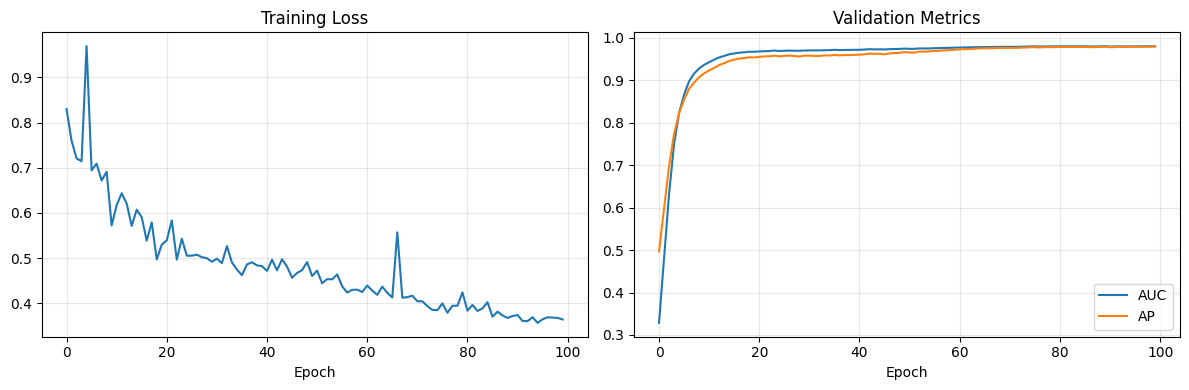

In [ ]:
best_val_auc = 0.0
best_state   = None
patience_cnt = 0
history      = {"loss": [], "val_auc": [], "val_ap": []}

print("── Training ──────────────────────────")
for epoch in range(1, EPOCHS + 1):
    # Reset memory at the start of each epoch (fresh chronological pass)
    node_memory.reset()

    loss = train_epoch(model, predictor, node_memory, optimizer,
                       train_data, DEVICE)
    val_auc, val_ap = evaluate(model, predictor, node_memory,
                               val_data, DEVICE)
    scheduler.step(1 - val_auc)

    history["loss"].append(loss)
    history["val_auc"].append(val_auc)
    history["val_ap"].append(val_ap)

    print(f"  Epoch {epoch:03d} | Loss {loss:.4f} | "
          f"Val AUC {val_auc:.4f} | Val AP {val_ap:.4f}")

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_state   = {
            "model":       {k: v.clone() for k, v in model.state_dict().items()},
            "predictor":   {k: v.clone() for k, v in predictor.state_dict().items()},
            "node_memory": {k: v.clone() for k, v in node_memory.state_dict().items()},
        }
        patience_cnt = 0
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f"  Early stopping at epoch {epoch}")
            break

# ── Test ──────────────────────────────────
model.load_state_dict(best_state["model"])
predictor.load_state_dict(best_state["predictor"])
node_memory.load_state_dict(best_state["node_memory"])

test_auc, test_ap = evaluate(model, predictor, node_memory, test_data, DEVICE)
print(f"\n── Test Results ──────────────────────")
print(f"  AUC-ROC : {test_auc:.4f}")
print(f"  Avg-Prec: {test_ap:.4f}")

# ── Training curves ───────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history["loss"])
ax1.set_title("Training Loss"); ax1.set_xlabel("Epoch"); ax1.grid(True, alpha=0.3)
ax2.plot(history["val_auc"], label="AUC")
ax2.plot(history["val_ap"],  label="AP")
ax2.set_title("Validation Metrics"); ax2.set_xlabel("Epoch")
ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("results/6/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

── Temporal Analysis ─────────────────
 window      t_start        t_end  nodes  edges  density  wcc  reciprocity  avg_clustering  mean_in_deg  mean_out_deg
      1 1.388507e+18 1.399013e+18  11634  34195  0.00025  239       0.1305          0.1551         2.94          2.94
      2 1.399013e+18 1.409520e+18  12954  38196  0.00023  310       0.1251          0.1441         2.95          2.95
      3 1.409520e+18 1.420026e+18  13489  40054  0.00022  337       0.1237          0.1404         2.97          2.97
      4 1.420026e+18 1.430533e+18  15783  48314  0.00019  338       0.1259          0.1419         3.06          3.06
      5 1.430533e+18 1.441039e+18  17737  55110  0.00018  411       0.1302          0.1438         3.11          3.11
      6 1.441039e+18 1.451546e+18  17772  53506  0.00017  464       0.1235          0.1361         3.01          3.01
      7 1.451546e+18 1.462052e+18  19734  57453  0.00015  556       0.1367          0.1299         2.91          2.91
      8 1.462052e

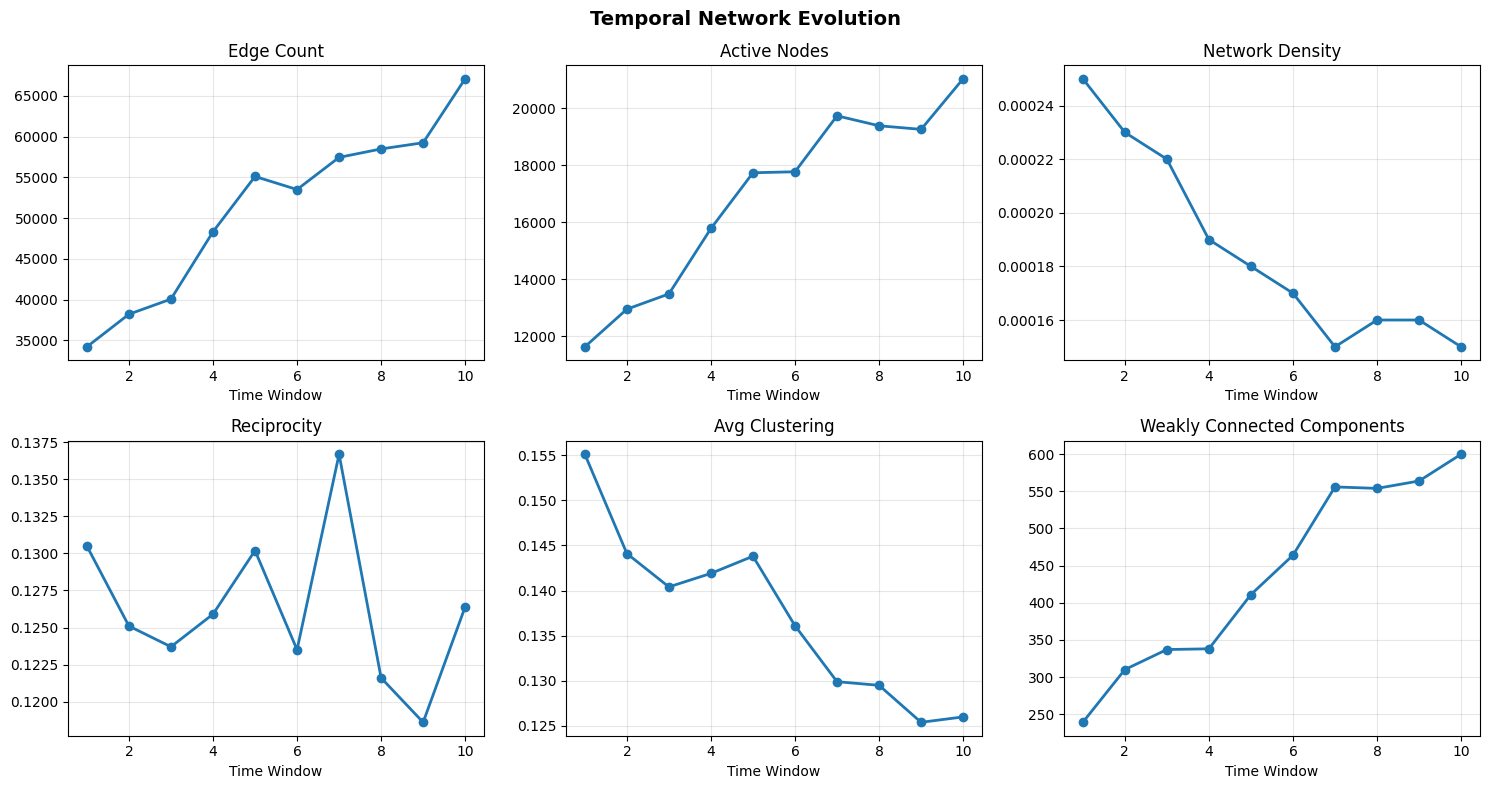

In [12]:
print("── Temporal Analysis ─────────────────")
stats_df = analyze_temporal_evolution(df, num_windows=10)
print(stats_df.to_string(index=False))
plot_temporal_analysis(stats_df)

In [13]:
print("── Memory Norms (top-10 most active nodes) ──")
mem_norms = node_memory.memory.norm(dim=1).cpu().numpy()
id2node   = {v: k for k, v in node2id.items()}
top10     = np.argsort(mem_norms)[::-1][:10]
print(f"  {'Node':>10}  {'Memory L2':>12}")
print("  " + "─" * 26)
for idx in top10:
    print(f"  {id2node[idx]:>10}  {mem_norms[idx]:>12.4f}")

── Memory Norms (top-10 most active nodes) ──
        Node     Memory L2
  ──────────────────────────
    rddtrust        0.4021
      stolen        0.4021
  progressives        0.4021
   vaporbowl        0.4021
  hungergamesrp        0.4021
  prehistoricrp        0.4021
  thedoctorstravels        0.4021
      mlptcg        0.4021
  championconcepts        0.4021
  jokesaboutgermany        0.4021


In [14]:
print("── Top-10 Predicted Future Links ─────")
model.eval(); predictor.eval(); node_memory.eval()
with torch.no_grad():
    all_ids = torch.arange(num_nodes, device=DEVICE)
    memory  = node_memory.get_memory(all_ids)
    z = model(test_data.x, memory, test_data.edge_index, test_data.edge_time)

existing = set(zip(df["src"].tolist(), df["tgt"].tolist()))
SAMPLE   = 5000
srcs     = np.random.randint(0, num_nodes, SAMPLE)
tgts     = np.random.randint(0, num_nodes, SAMPLE)
valid    = [(s, t) for s, t in zip(srcs, tgts)
            if s != t and (s, t) not in existing][:SAMPLE]

vs = torch.tensor([p[0] for p in valid], dtype=torch.long, device=DEVICE)
vt = torch.tensor([p[1] for p in valid], dtype=torch.long, device=DEVICE)
with torch.no_grad():
    scores = torch.sigmoid(predictor(z[vs], z[vt])).cpu().numpy()

top_idx = np.argsort(scores)[::-1][:10]
print(f"  {'Src':>10}  {'Tgt':>10}  {'Score':>8}")
print("  " + "─" * 34)
for i in top_idx:
    s, t, sc = valid[i][0], valid[i][1], scores[i]
    print(f"  {id2node[s]:>10}  {id2node[t]:>10}  {sc:>8.4f}")

── Top-10 Predicted Future Links ─────
         Src         Tgt     Score
  ──────────────────────────────────
     thesims    survivor    0.9999
  utarlington  depression    0.9469
  simonfraser  rupaulsdragrace    0.9439
  sexoffendersupport     faceoff    0.9334
  marksmanmains      celebs    0.9274
        qmee  wholesomestarterpacks    0.9259
       rumer  learnuselesstalents    0.9258
    teamevga   lifehacks    0.9257
      cuecat    churning    0.9257
        usde  shittylifeprotips    0.9257


In [ ]:
torch.save({
    "model":       model.state_dict(),
    "predictor":   predictor.state_dict(),
    "node_memory": node_memory.state_dict(),
    "node2id":     node2id,
    "config": {
        "num_nodes": num_nodes, "mem_dim": MEM_DIM,
        "time_dim": TIME_DIM, "hidden": HIDDEN, "out_dim": OUT_DIM,
    }
}, "results/6/tgnn_memory_model.pt")